### Spatial transcriptomics cell type and L-R pair interaction mapping
This notebook is an introductory guide to spatial transcriptomics analysis, using a toy [10X Genomics](https://www.10xgenomics.com/datasets?configure%5BhitsPerPage%5D=50&configure%5BmaxValuesPerFacet%5D=1000) Visium dataset from Python's `scanpy` package.

It demonstrates foundational analysis methods like EDA, PCA and cell type mapping analysis using `squidpy`. As a slightly advanced bonus, it introduces ligand-receptor pair mapping for inferring cell-cell communication.

Note that the analysis here is intended solely for educational purposes and not to derive biologically meaningful insight.

In [ ]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# load spatial data
adata = sc.datasets.visium_sge()
adata.var_names_make_unique() # optional but good practice


/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/ipykernel_63964/1885918932.py:10: FutureWarning: Use `squidpy.datasets.visium` instead.
  adata = sc.datasets.visium_sge()
/Users/aneesavalentine/tms/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 9.50M/9.50M [00:00<00:00, 60.5MB/s]
100%|██████████| 26.9M/26.9M [00:00<00:00, 61.0MB/s]
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/datasets/_datasets.py:555: FutureWarning: Use `squidpy.read.visium` instead.
  return read_visium(sample_dir, source_image_path=source_image_path)
/Users/aneesavalentine/tms/lib/python3.13/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/aneesavalentine/tms/lib/

In [31]:
adata

AnnData object with n_obs × n_vars = 3798 × 36601
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [ ]:
# pre-processing
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)
adata = adata[:, adata.var.highly_variable]

# redcuce dims
sc.pp.scale(adata)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.umap(adata)
sc.tl.leiden(adata)

/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/usr/local/Cellar/python@3.13/3.13.1/Frameworks/Python.framework/Versions/3.13/lib/python3.13/functools.py:931: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
# check
adata.obs['leiden']

AAACAAGTATCTCCCA-1    0
AAACACCAATAACTGC-1    1
AAACAGAGCGACTCCT-1    0
AAACAGGGTCTATATT-1    6
AAACAGTGTTCCTGGG-1    1
                     ..
TTGTTGTGTGTCAAGA-1    3
TTGTTTCACATCCAGG-1    1
TTGTTTCATTAGTCTA-1    1
TTGTTTCCATACAACT-1    0
TTGTTTGTGTAAATTC-1    8
Name: leiden, Length: 3798, dtype: category
Categories (13, object): ['0', '1', '2', '3', ..., '9', '10', '11', '12']

In [ ]:
# check
print(adata.obsm['spatial'])

[[17428 15937]
 [ 6092 18054]
 [16351  7383]
 ...
 [ 7593 18294]
 [ 7190 14730]
 [10484  5709]]


/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/ipykernel_63964/31618670.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='leiden', spot_size=100)


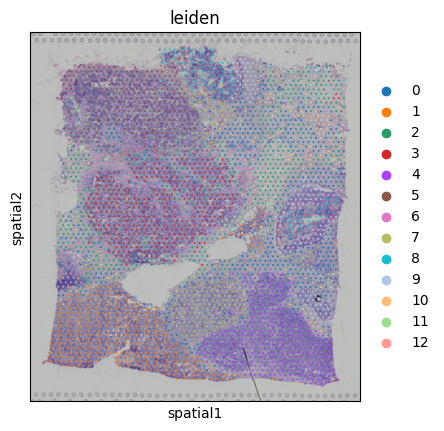

In [44]:
# visualize clusters
sc.pl.spatial(adata, color='leiden', spot_size=100)

/var/folders/bd/djhgjhzs6rx_1ffvlb2ncd8c0000gn/T/ipykernel_63964/416291368.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color='MALAT1', spot_size=100)  # to confirm plotting works in general


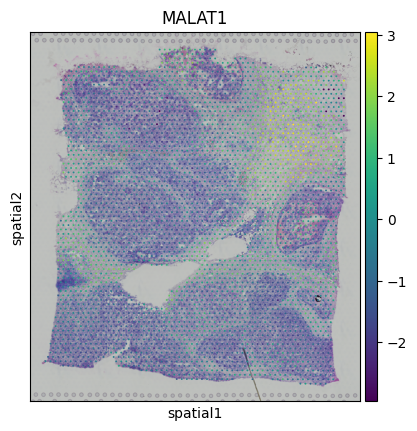

In [ ]:
# spatially map a single gene of interest
sc.pl.spatial(adata, color='MALAT1', spot_size=100)


In [ ]:
# check
adata.uns['spatial'].keys()

dict_keys(['V1_Breast_Cancer_Block_A_Section_1'])

/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


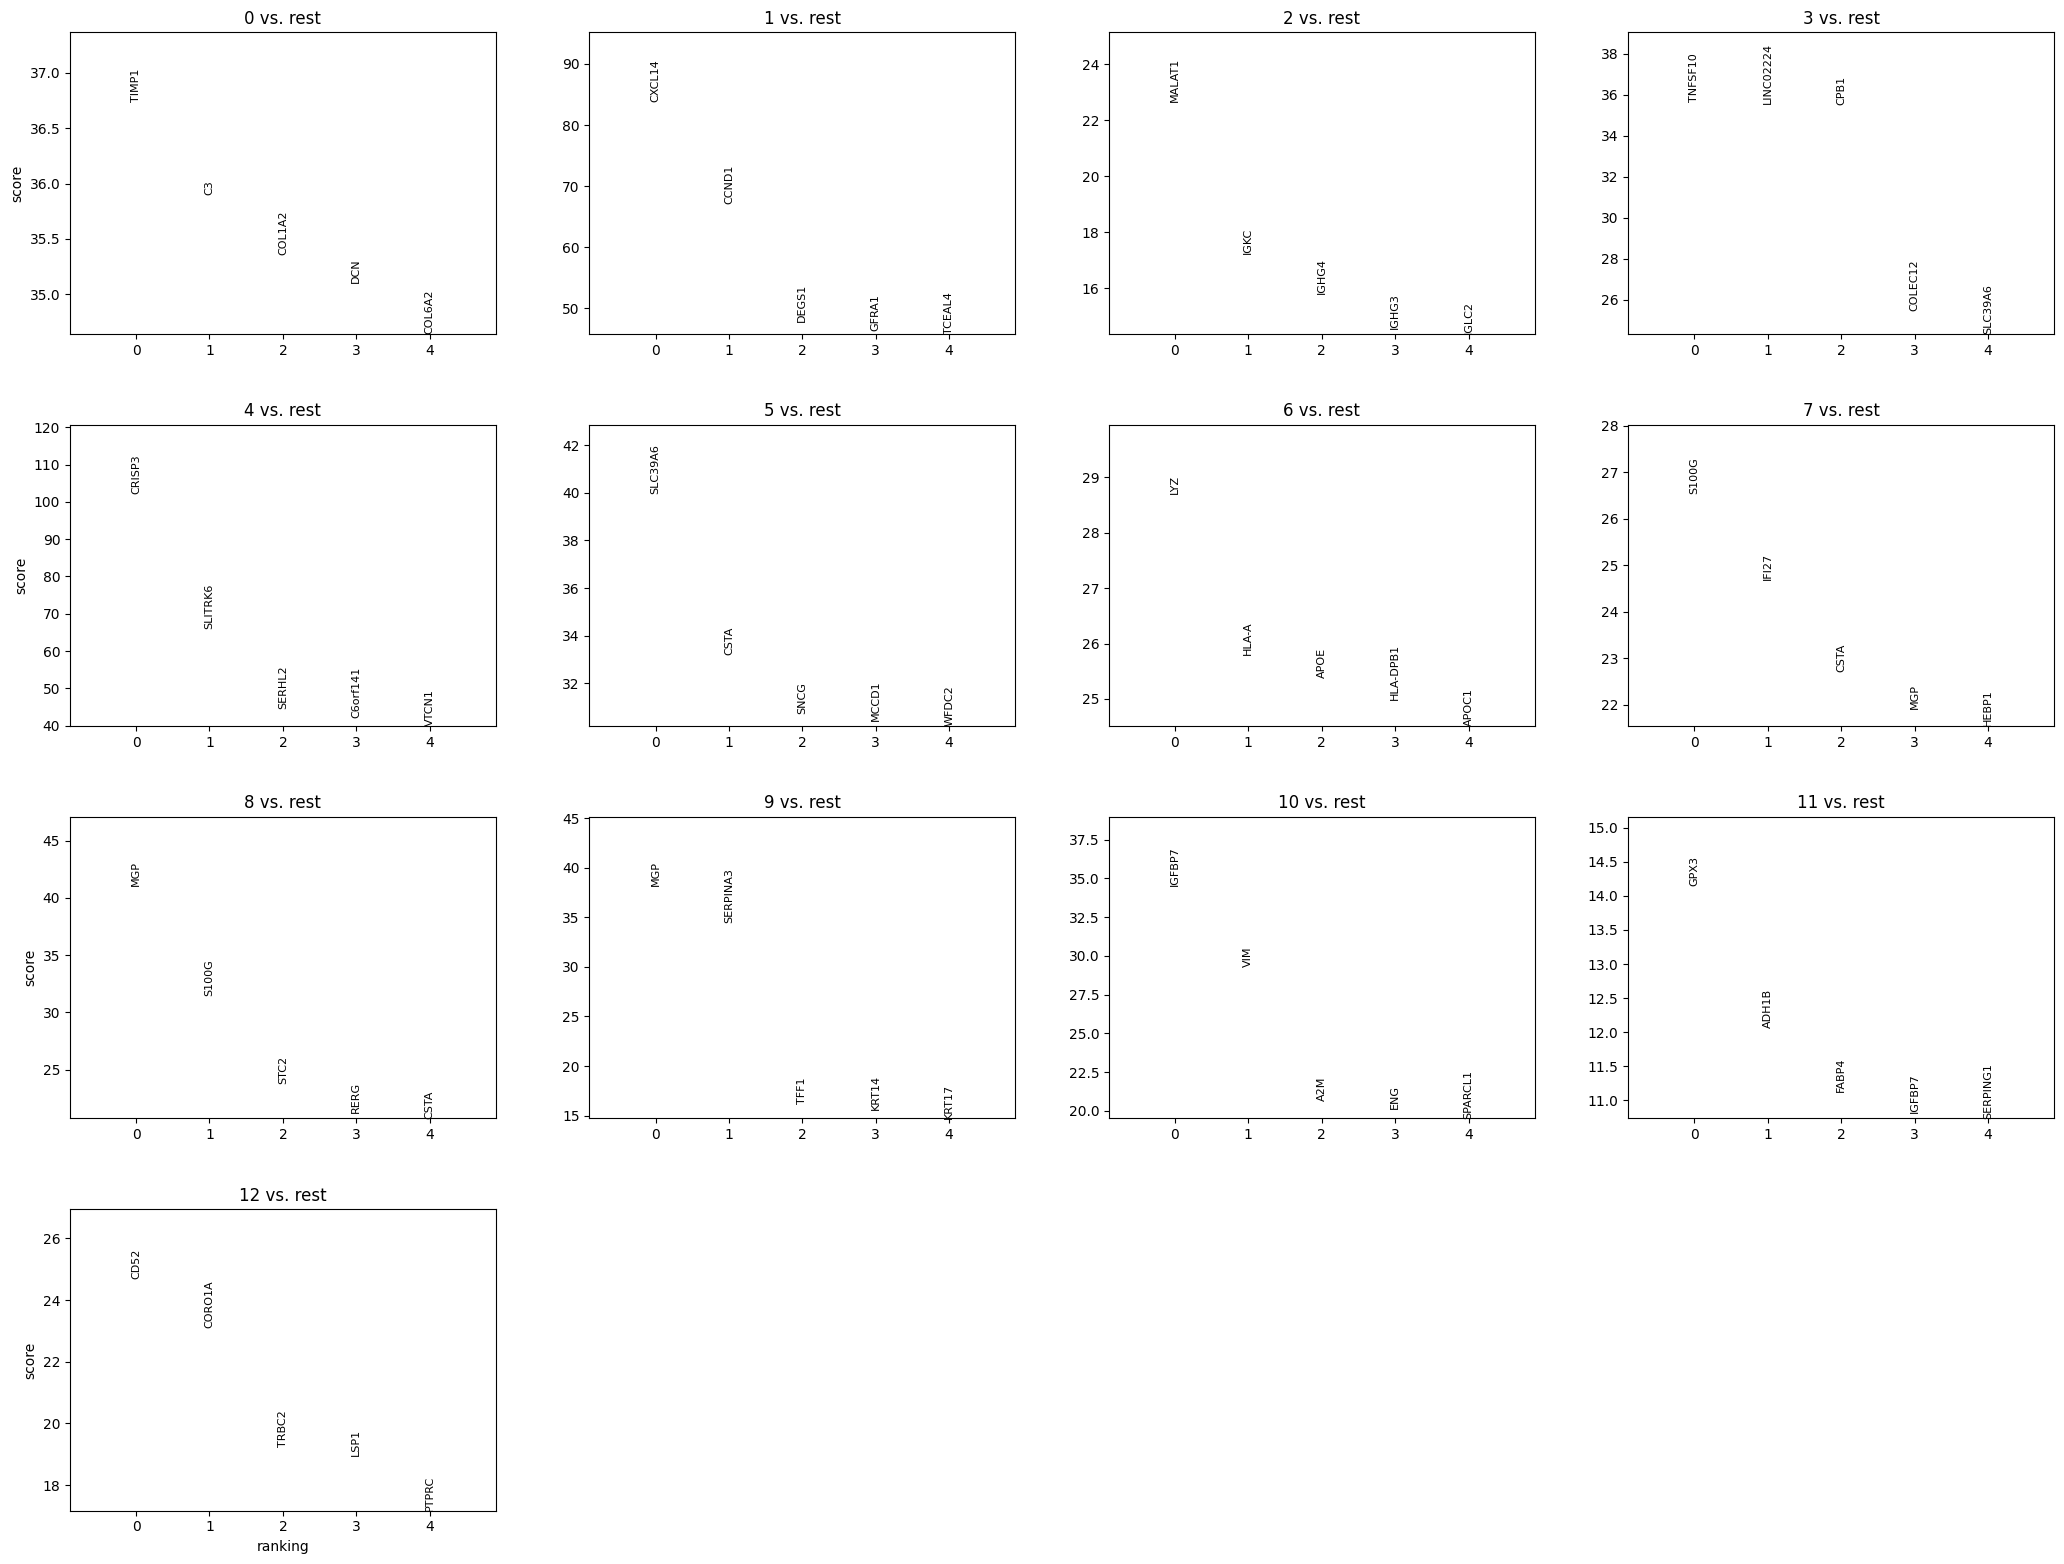

In [46]:
# identify marker genes
sc.tl.rank_genes_groups(adata, 'leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

Let's map relationships between cells to help us understand spatial gene expression in our tissue.

In [47]:
# spatial neighborhood enrichment
sq.gr.spatial_neighbors(adata)
sq.gr.spatial_autocorr(adata, mode='moran')


In [ ]:
# check
adata.uns["moranI"].keys()

Index(['I', 'pval_norm', 'var_norm', 'pval_norm_fdr_bh'], dtype='object')

In [ ]:
# check
adata.uns["moranI"]

,I,pval_norm,var_norm,pval_norm_fdr_bh
MGP,0.868505,0.000000,0.000092,0.000000
MALAT1,0.762557,0.000000,0.000092,0.000000
CRISP3,0.726323,0.000000,0.000092,0.000000
CPB1,0.711018,0.000000,0.000092,0.000000
IGHG3,0.703822,0.000000,0.000092,0.000000
...,...,...,...,...
C1RL-AS1,-0.014175,0.073242,0.000092,0.146191
TFE3,-0.016625,0.043840,0.000092,0.090989
ADAMTSL1,-0.017762,0.033890,0.000092,0.071123
THUMPD1,-0.019867,0.020370,0.000092,0.043666


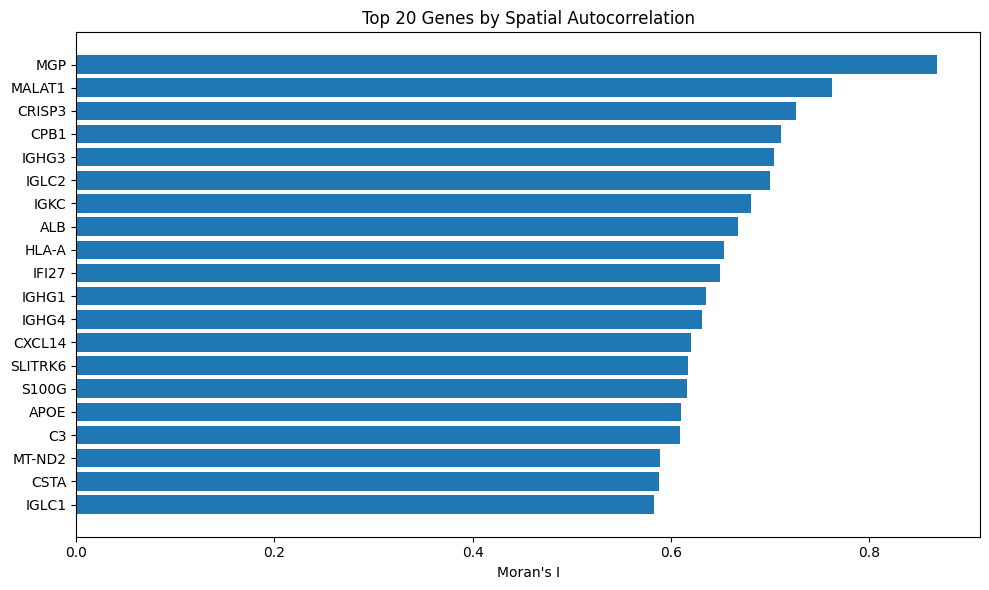

In [ ]:
# convert result to df
moran_df = pd.DataFrame(adata.uns['moranI'])

# set gene names as col (instead of index)
moran_df = moran_df.reset_index().rename(columns={"index": "gene"})

# sort by Moran's I value
moran_df_sorted = moran_df.sort_values("I", ascending=False)

# plot top 20 genes
top_n = 20
plt.figure(figsize=(10, 6))
plt.barh(
    moran_df_sorted['gene'][:top_n][::-1],   # reverse for descending y-axis
    moran_df_sorted['I'][:top_n][::-1]
)
plt.xlabel("Moran's I")
plt.title(f"Top {top_n} Genes by Spatial Autocorrelation")
plt.tight_layout()
plt.show()

Now let's analyze ligand-receptor interations between our cell clusters for inferring potential cell-cell communication pathways.

  0%|          | 0/100 [00:00<?, ?permutation/s]/Users/aneesavalentine/tms/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/aneesavalentine/tms/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/aneesavalentine/tms/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wr

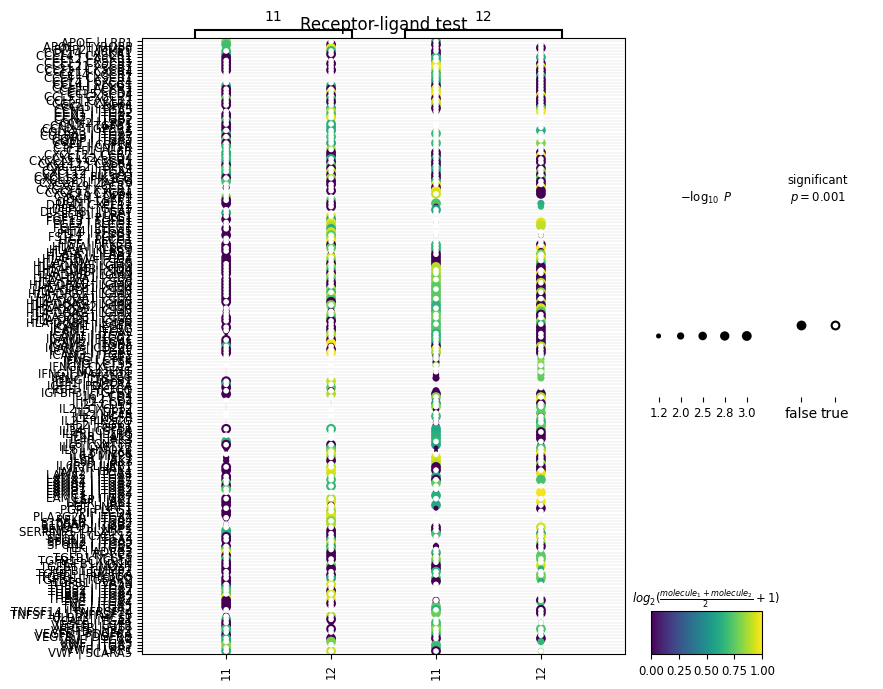

In [ ]:
sq.gr.ligrec(adata, n_perms=100, cluster_key='leiden', use_raw=False)
sq.pl.ligrec(adata, cluster_key='leiden', means_range=(0.5, 1), figsize=(8, 8))

The plot above is messy, so instead, let's only plot L-R interactions from specific cell clusters (i.e, 11 and 12).

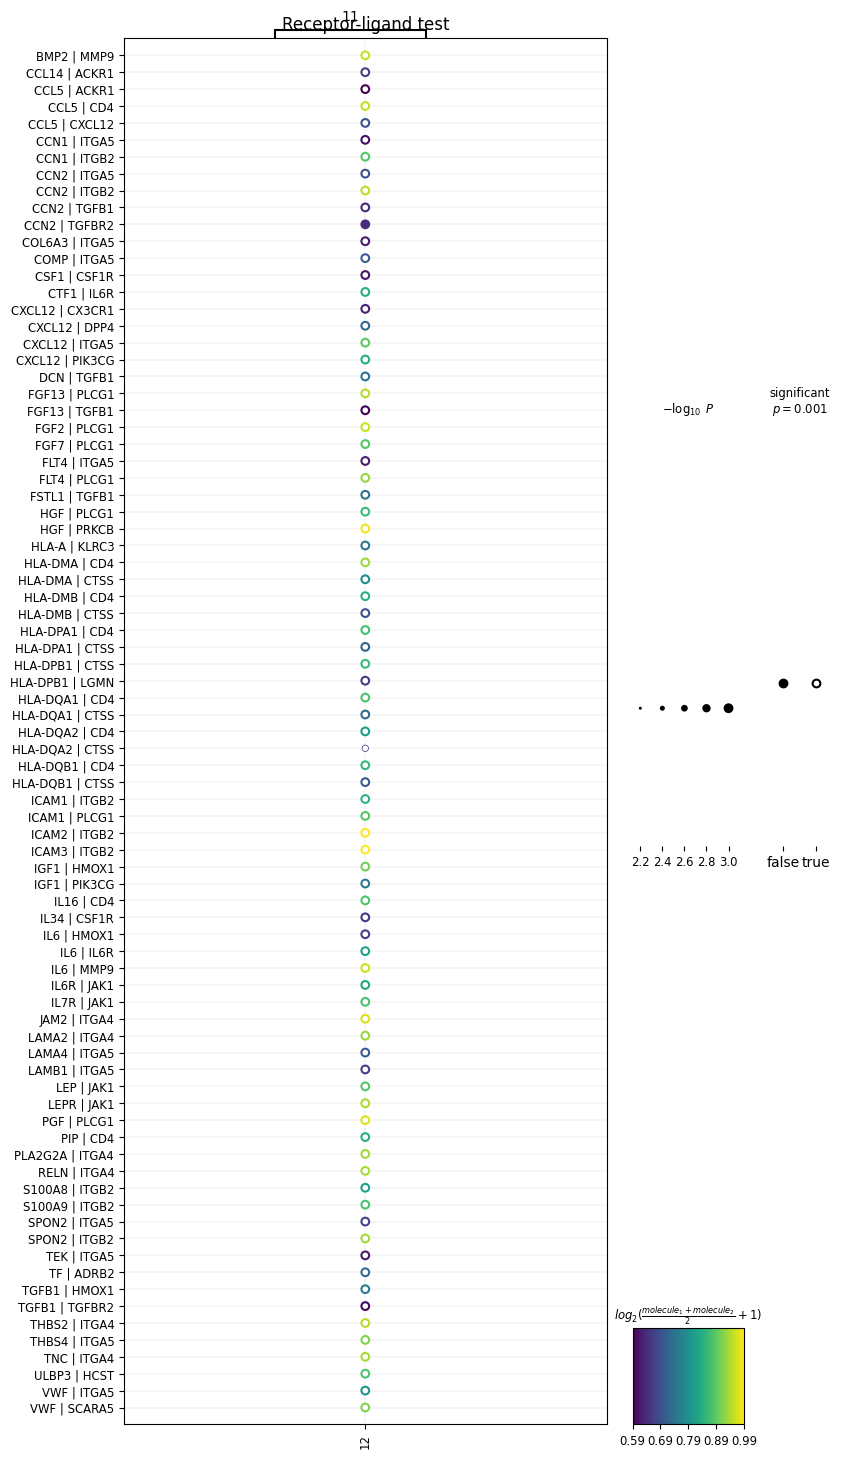

In [ ]:
# plot only specific clusters
sq.pl.ligrec(
    adata,
    cluster_key='leiden',
    source_groups=['11'],
    target_groups=['12'],
    figsize=(8, 18),
    means_range=(0.5, 1)
)


In [ ]:
# save .h5ad
#adata.write("spatial_analysis_result.h5ad")